# 06 market data

we pull a live AAPL options chain using yfinance, estimate historical volatility from real price data, and compare our Black-Scholes prices to what is being charged for the options. we will see that there will be a gap between the market price and the model price, because volatility is of course not constant, which the Black-Scholes model assumes, with $\sigma$ being constant.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
from pricer import bs_pricing

## stock data + historical volatility

we estimate historical volatility $\sigma$ based on the last year's worth (252 trading days) of AAPL daily returns. this estimate will be different from implied volatility that the market uses to price into options, which will cause the gap between the market price and the model price.

In [2]:
ticker = yf.Ticker("AAPL")

# pull one year of daily prices
hist = ticker.history(period="1y")
hist.index = hist.index.tz_localize(None)

# compute daily log returns
log_returns = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()

# annualise volatility: daily vol * sqrt(252)
hist_vol = log_returns.std() * np.sqrt(252)

# current stock price
Sof0 = hist['Close'].iloc[-1]

print(f"Current AAPL price    : ${Sof0:.2f}")
print(f"Historical volatility : {hist_vol:.2%}")

Current AAPL price    : $254.42
Historical volatility : 31.41%


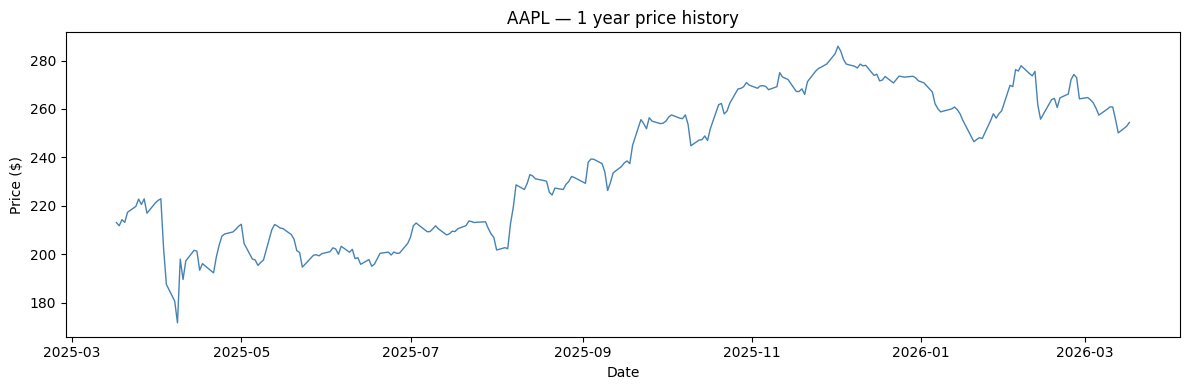

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(hist.index, hist['Close'], color='steelblue', linewidth=1.0)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.title('AAPL — 1 year price history')
plt.tight_layout()
plt.show()

## options chain

we pick an expiry time a number of months out. we can then pull market prices, bid/ask spreads, and implied volatility for each contract.

In [4]:
# print available expiry dates
print("Available expiries:")
for i, exp in enumerate(ticker.options):
    print(f"  [{i}] {exp}")

Available expiries:
  [0] 2026-03-18
  [1] 2026-03-20
  [2] 2026-03-23
  [3] 2026-03-25
  [4] 2026-03-27
  [5] 2026-04-02
  [6] 2026-04-10
  [7] 2026-04-17
  [8] 2026-04-24
  [9] 2026-05-01
  [10] 2026-05-15
  [11] 2026-06-18
  [12] 2026-07-17
  [13] 2026-08-21
  [14] 2026-09-18
  [15] 2026-10-16
  [16] 2026-11-20
  [17] 2026-12-18
  [18] 2027-01-15
  [19] 2027-03-19
  [20] 2027-06-17
  [21] 2027-12-17
  [22] 2028-01-21
  [23] 2028-03-17
  [24] 2028-12-15


In [5]:
# pick an expiry — change the index to choose a different one
expiry = ticker.options[int(input())]
print(f"Using expiry: {expiry}")

chain  = ticker.option_chain(expiry)
calls  = chain.calls.copy()

# compute time to expiry in years
expiry_date = datetime.strptime(expiry, "%Y-%m-%d")
T = (expiry_date - datetime.today()).days / 365
r = 0.05  # approximate risk-free rate

print(f"Time to expiry: {T:.3f} years ({(T*365):.0f} days)")
print(f"\nColumns available: {list(calls.columns)}")

Using expiry: 2026-06-18
Time to expiry: 0.252 years (92 days)

Columns available: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']


In [6]:
# clean the chain — keep liquid strikes near the current price
calls = calls[calls['volume'] > 0].copy()
calls = calls[(calls['strike'] > Sof0 * 0.7) &
              (calls['strike'] < Sof0 * 1.3)].copy()

# use mid-price as the market price
calls['mid_price'] = (calls['bid'] + calls['ask']) / 2
calls = calls[calls['mid_price'] > 0.10].copy()

print(f"Strikes after filtering: {len(calls)}")
calls[['strike', 'bid', 'ask', 'mid_price', 'impliedVolatility', 'volume']].head(10)

Strikes after filtering: 31


,strike,bid,ask,mid_price,impliedVolatility,volume
35,180.0,76.20,77.60,76.900,0.518437,2
36,185.0,71.60,72.25,71.925,0.504033,1
37,190.0,66.90,67.55,67.225,0.485479,1
38,195.0,62.25,62.90,62.575,0.467779,5
39,200.0,57.65,58.25,57.950,0.448614,1
40,205.0,53.15,53.70,53.425,0.431768,2
41,210.0,48.70,49.30,49.000,0.418036,5
42,215.0,44.35,44.80,44.575,0.398993,4
43,220.0,40.10,40.70,40.400,0.389349,1
44,225.0,35.80,36.35,36.075,0.370185,1


## Black-Scholes for pricing strikes

we run our `bs_pricing` function on each strike using the
historical volatility we estimated. Then we compare to the
market mid-price.

In [7]:
print(f"Historical Volatility : {hist_vol:.2%}")
calls['bs_price'] = calls['strike'].apply(
    lambda K: bs_pricing(Sof0, K, r, hist_vol, T, option_type='call')
)

calls['pricing_error'] = calls['bs_price'] - calls['mid_price']

calls[['strike', 'mid_price', 'bs_price', 'pricing_error', 'impliedVolatility']].round(3)

Historical Volatility : 31.41%


,strike,mid_price,bs_price,pricing_error,impliedVolatility
35,180.0,76.900,76.806,-0.094,0.518
36,185.0,71.925,71.956,0.031,0.504
37,190.0,67.225,67.150,-0.075,0.485
38,195.0,62.575,62.403,-0.172,0.468
39,200.0,57.950,57.733,-0.217,0.449
40,205.0,53.425,53.160,-0.265,0.432
41,210.0,49.000,48.707,-0.293,0.418
42,215.0,44.575,44.396,-0.179,0.399
43,220.0,40.400,40.248,-0.152,0.389
44,225.0,36.075,36.286,0.211,0.370


## the volatility smile

if Black-Scholes were a perfect model, our historical volatility estimate would price every option correctly. instead, we see a systematic pattern, where the market charges more for out-of-the-money options than the model predicts; this is the volatility smile. the market implicitly uses a higher $\sigma$ for strikes far from the current price. it reflects the market's fear of large moves and fat tails that the normal distribution in GBM underestimates.

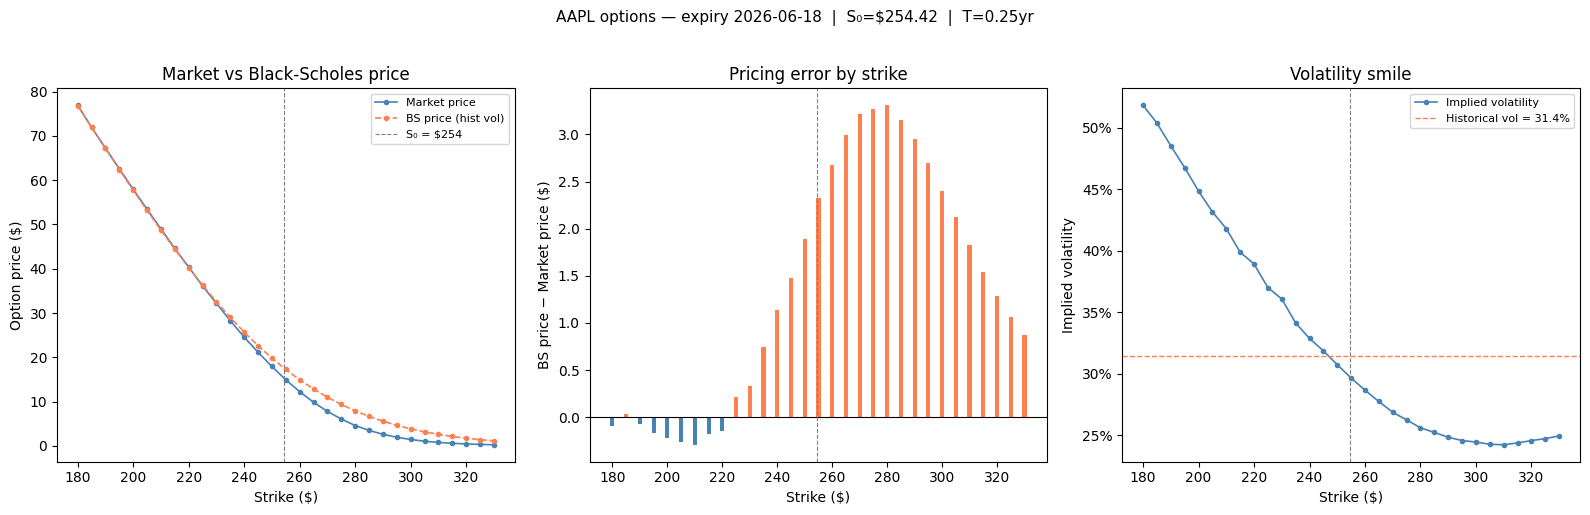

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# plot 1: market price vs BS price across strikes
axes[0].plot(calls['strike'], calls['mid_price'],
             color='steelblue', linewidth=1.2, marker='o',
             markersize=3, label='Market price')
axes[0].plot(calls['strike'], calls['bs_price'],
             color='coral', linewidth=1.2, linestyle='--',
             marker='o', markersize=3, label='BS price (hist vol)')
axes[0].axvline(Sof0, color='gray', linestyle='--',
                linewidth=0.8, label=f'S₀ = ${Sof0:.0f}')
axes[0].set_xlabel('Strike ($)')
axes[0].set_ylabel('Option price ($)')
axes[0].set_title('Market vs Black-Scholes price')
axes[0].legend(fontsize=8)

# plot 2: pricing error across strikes
axes[1].bar(calls['strike'], calls['pricing_error'],
            color=np.where(calls['pricing_error'] > 0, 'coral', 'steelblue'),
            width=1.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(Sof0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Strike ($)')
axes[1].set_ylabel('BS price − Market price ($)')
axes[1].set_title('Pricing error by strike')

# plot 3: the volatility smile
axes[2].plot(calls['strike'], calls['impliedVolatility'],
             color='steelblue', linewidth=1.2, marker='o', markersize=3,
             label='Implied volatility')
axes[2].axhline(hist_vol, color='coral', linestyle='--',
                linewidth=1.0, label=f'Historical vol = {hist_vol:.1%}')
axes[2].axvline(Sof0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Strike ($)')
axes[2].set_ylabel('Implied volatility')
axes[2].set_title('Volatility smile')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[2].legend(fontsize=8)

plt.suptitle(f'AAPL options — expiry {expiry}  |  S₀=${Sof0:.2f}  |  T={T:.2f}yr',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## what the smile tells us

we see three things:

1. Black-Scholes uses a single $\sigma$ for all strikes. the market doesn't, instead it prices each strike with a different implied vol. the smile is the market's correction to the model.

2. out-of-the-money puts are expensive. for equities, the smile is really a skew, where implied volatility rises sharply for low strikes because the market fears crashes more than it expects rallies. institutions buy out-of-the-money puts as portfolio insurance, driving up their price.

3. fat tails: real stock returns have more extreme moves than a normal distribution predicts, which causes the market to  prices it in. something called the Heston model directly addresses this by letting volatility itself be random.